# Can log g be photometrically determined? The dwarf/giant separability map

Notebook 06 showed the five-band fit (LSST u, CaHK, g, r, i; μ free) returns
a log g-bimodal posterior at survey depths — but also that the bands *do*
carry gravity information locally (conditional CRLB 0.1–0.3 dex). This
notebook asks the sharp question directly: **is a giant's five-band SED
distinguishable from every dwarf SED at all**, and in which (Teff, [Fe/H])
regime?

The metric: for a noiseless target star of one class, the χ² distance to the
*best-matching* star of the other class, minimized over the impostor's
(Teff′, [Fe/H]′, log g′ within its class, μ′ analytic) —

$$ D = \min_{\rm impostor} \sqrt{\chi^2}, \qquad
   \chi^2 = \sum_k \frac{(\Delta m_k - \mu^*)^2}{\sigma_k^2} $$

D is the separation significance available to *any* estimator (the NSS fit,
a color-color cut, anything): D ≲ 1 means the classes are fundamentally
confused at these depths, D ≳ 2–3 means photometric classification works.
Because χ² is quadratic in the errors, scaling every σ by a factor f scales
D by 1/f — so one map answers "how deep would we need to go" everywhere.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import StarModel, load_photometry_grid, make_nss_pipeline

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(37)

## 1. Setup — same bands and depths as notebook 06

In [2]:
BANDS = ("lsst_u_ab", "CaHK_filter_ab", "lsst_g_ab", "lsst_r_ab", "lsst_i_ab")
SHORT = ("u", "CaHK", "g", "r", "i")
SIGMA = np.array([0.05, 0.03, 0.02, 0.02, 0.02])  # baseline 1σ errors [mag]

grid = load_photometry_grid(
    DATA / "TSLTE_combined_photometry.fits", filter_columns=BANDS, fill="nearest"
)
model = StarModel(grid=grid, interp_method="pchip")

LOGG_RGB, LOGG_MS = 2.0, 4.6
mags_at = jax.jit(jax.vmap(lambda t, g, f: model.predict_mags(teff=t, logg=g, feh=f)))


def manifold(teffs, fehs, loggs):
    """Magnitudes on a (teff × feh × logg) lattice, flattened to (N, 5)."""
    T, F, G = np.meshgrid(teffs, fehs, loggs, indexing="ij")
    args = (jnp.asarray(T.ravel()), jnp.asarray(G.ravel()), jnp.asarray(F.ravel()))
    return np.asarray(mags_at(*args))


# Impostor libraries: the full plausible manifold of the *other* class.
LIB_TEFF = np.linspace(3900.0, 7000.0, 125)
LIB_FEH = np.linspace(-5.0, 1.0, 49)
lib_dwarf = manifold(LIB_TEFF, LIB_FEH, np.array([4.2, 4.6, 5.0]))
lib_giant = manifold(LIB_TEFF, LIB_FEH, np.array([0.8, 1.5, 2.2, 2.9]))
print(f"impostor libraries: dwarf {lib_dwarf.shape}, giant {lib_giant.shape}")


def sep_map(targets, lib, sigma, chunk=200):
    """min-χ² separation D for each target row against the library, μ analytic."""
    w = 1.0 / sigma**2
    W = w.sum()
    out = np.empty(len(targets))
    for i in range(0, len(targets), chunk):
        d = lib[None, :, :] - targets[i : i + chunk, None, :]  # (c, N, 5)
        chi2 = (d**2) @ w - ((d @ w) ** 2) / W
        out[i : i + chunk] = np.sqrt(np.maximum(chi2.min(axis=1), 0.0))
    return out

impostor libraries: dwarf (18375, 5), giant (24500, 5)


## 2. Separability maps at baseline depth

D(Teff, [Fe/H]) for true giants against the dwarf manifold and vice versa.
Contours at D = 1 (confused), 2 (usable), 3 (clean).

two 60×48 maps in 1.9s


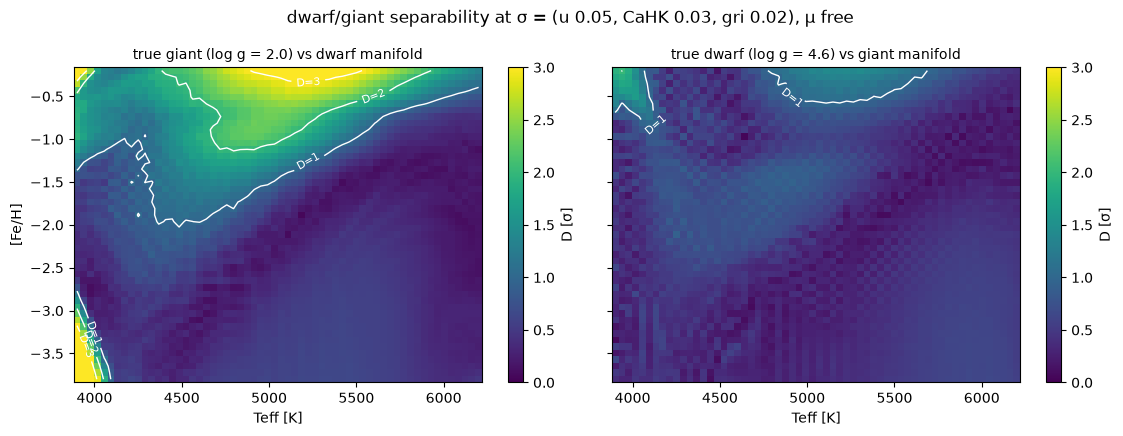

true giant: 11% of map has D > 2; max D = 6.1 at Teff 3900, [Fe/H] -3.8
true dwarf: 0% of map has D > 2; max D = 2.0 at Teff 3939, [Fe/H] -0.2


In [3]:
teff_map = np.linspace(3900.0, 6200.0, 60)
feh_map = np.linspace(-3.8, -0.2, 48)
TT, FF = np.meshgrid(teff_map, feh_map)

targets_g = np.asarray(
    mags_at(jnp.asarray(TT.ravel()), jnp.full(TT.size, LOGG_RGB), jnp.asarray(FF.ravel()))
)
targets_d = np.asarray(
    mags_at(jnp.asarray(TT.ravel()), jnp.full(TT.size, LOGG_MS), jnp.asarray(FF.ravel()))
)

t0 = time.time()
D_giant = sep_map(targets_g, lib_dwarf, SIGMA).reshape(TT.shape)
D_dwarf = sep_map(targets_d, lib_giant, SIGMA).reshape(TT.shape)
print(f"two 60×48 maps in {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, D, title in ((axes[0], D_giant, "true giant (log g = 2.0) vs dwarf manifold"),
                     (axes[1], D_dwarf, "true dwarf (log g = 4.6) vs giant manifold")):
    im = ax.pcolormesh(TT, FF, D, vmin=0, vmax=3.0, cmap="viridis")
    cs = ax.contour(TT, FF, D, levels=[1.0, 2.0, 3.0], colors="w", linewidths=1.0)
    ax.clabel(cs, fmt="D=%.0f", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Teff [K]")
    fig.colorbar(im, ax=ax, label="D [σ]")
axes[0].set_ylabel("[Fe/H]")
fig.suptitle("dwarf/giant separability at σ = (u 0.05, CaHK 0.03, gri 0.02), μ free")
fig.tight_layout()
plt.show()

for name, D in (("giant", D_giant), ("dwarf", D_dwarf)):
    frac2 = float((D > 2.0).mean())
    best = np.unravel_index(np.argmax(D), D.shape)
    print(f"true {name}: {frac2:.0%} of map has D > 2; "
          f"max D = {D.max():.1f} at Teff {TT[best]:.0f}, [Fe/H] {FF[best]:+.1f}")

## 3. Where does the discriminating signal live?

Residuals (target − best impostor, μ removed) per band, in σ units, at
representative points — which bands actually tell a giant from its closest
dwarf mimic.

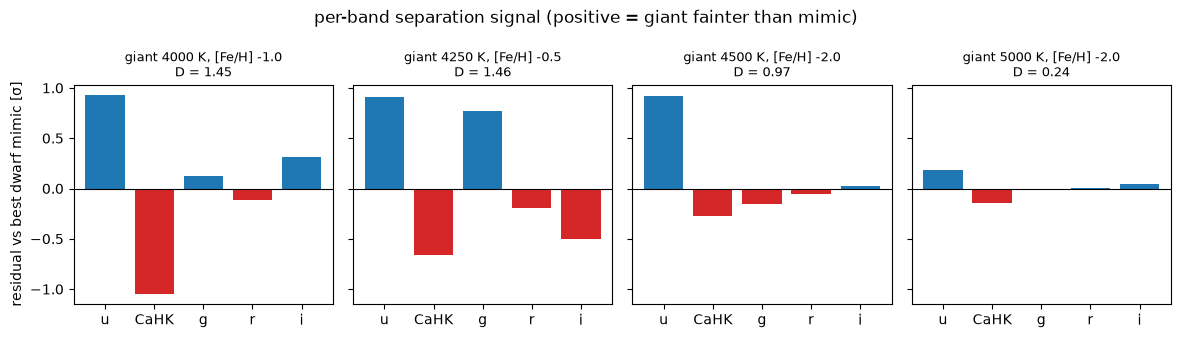

In [4]:
POINTS = ((4000.0, -1.0), (4250.0, -0.5), (4500.0, -2.0), (5000.0, -2.0))
w = 1.0 / SIGMA**2
fig, axes = plt.subplots(1, len(POINTS), figsize=(3.0 * len(POINTS), 3.4), sharey=True)
for ax, (teff, feh) in zip(axes, POINTS):
    tm = np.asarray(model.predict_mags(teff=teff, logg=LOGG_RGB, feh=feh))
    d = lib_dwarf - tm
    chi2 = (d**2) @ w - ((d @ w) ** 2) / w.sum()
    best = int(np.argmin(chi2))
    resid = d[best] - (d[best] @ w) / w.sum()
    ax.bar(SHORT, resid / SIGMA, color=["C0" if v >= 0 else "C3" for v in resid])
    ax.axhline(0, color="k", lw=0.8)
    title = f"giant {teff:.0f} K, [Fe/H] {feh:+.1f}\nD = {np.sqrt(chi2[best]):.2f}"
    ax.set_title(title, fontsize=9)
axes[0].set_ylabel("residual vs best dwarf mimic [σ]")
fig.suptitle("per-band separation signal (positive = giant fainter than mimic)")
fig.tight_layout()
plt.show()

## 4. How deep would the photometry need to be?

Scaling all five σ by f scales D by 1/f, so the depth factor required for a
2σ separation is simply 2/D. Below: that factor for true giants, and the
u-depth-only variant (σ_u ∈ {0.05, 0.02, 0.01}, other bands fixed) — since
§3 shows u carries most of the signal, deepening u alone is the realistic
lever.

σ_u=0.05: 11% of map separable at D>2 (true giants)


σ_u=0.02: 19% of map separable at D>2 (true giants)


σ_u=0.01: 23% of map separable at D>2 (true giants)


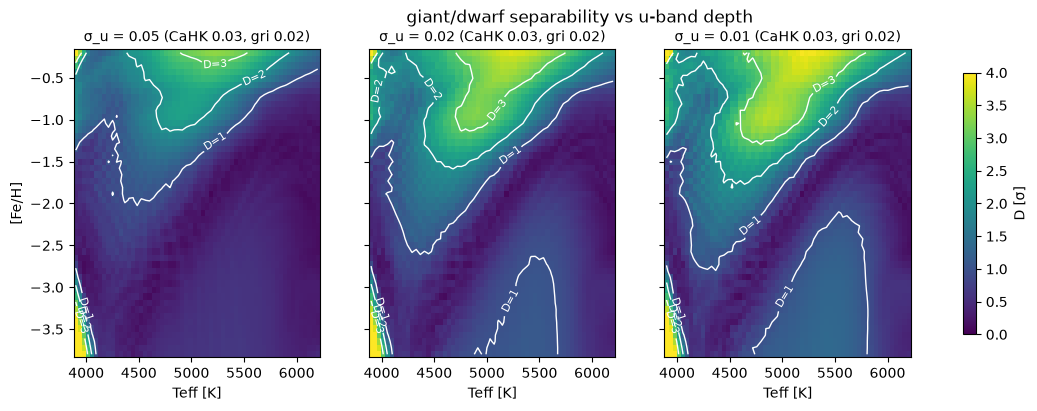

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharey=True)
for ax, sig_u in zip(axes, (0.05, 0.02, 0.01)):
    sigma_v = SIGMA.copy()
    sigma_v[0] = sig_u
    D = sep_map(targets_g, lib_dwarf, sigma_v).reshape(TT.shape)
    im = ax.pcolormesh(TT, FF, D, vmin=0, vmax=4.0, cmap="viridis")
    cs = ax.contour(TT, FF, D, levels=[1.0, 2.0, 3.0], colors="w", linewidths=1.0)
    ax.clabel(cs, fmt="D=%.0f", fontsize=8)
    ax.set_title(f"σ_u = {sig_u:.2f} (CaHK 0.03, gri 0.02)", fontsize=10)
    ax.set_xlabel("Teff [K]")
    print(f"σ_u={sig_u:.2f}: {(D > 2.0).mean():.0%} of map separable at D>2 (true giants)")
fig.colorbar(im, ax=axes, label="D [σ]", shrink=0.85)
axes[0].set_ylabel("[Fe/H]")
fig.suptitle("giant/dwarf separability vs u-band depth")
plt.show()

## 5. Posterior validation: does the joint fit realize D?

NSS fits (μ free, flat priors) at three regime points × two overall depths.
Prediction: P(correct branch) tracks D — coin flip where D ≲ 1, decisive
where D ≳ 2–3.

In [6]:
priors = {
    "teff": Uniform(float(grid.axes[0][0]), float(grid.axes[0][-1])),
    "logg": Uniform(float(grid.axes[1][0]), float(grid.axes[1][-1])),
    "feh": Uniform(float(grid.axes[2][0]), float(grid.axes[2][-1])),
    "mu": Uniform(-28.0, -8.0),
}
LOGG_CUT = 3.3
MU_TRUE = -18.0
N_SEEDS = 3
TEST_POINTS = ((4000.0, -1.0), (4500.0, -2.0), (5000.0, -2.0))
DEPTH_FACTORS = (1.0, 0.5)  # all-band scaling: baseline and 2× deeper

pipes = {}
for f in DEPTH_FACTORS:
    sig_f = jnp.asarray(SIGMA * f)

    def loglik(params, data, _sig=sig_f):
        pred = model.predict_mags(
            teff=params["teff"], logg=params["logg"], feh=params["feh"], mu=params["mu"]
        )
        return jnp.sum(-0.5 * ((data - pred) / _sig) ** 2)

    pipes[f] = make_nss_pipeline(loglik, priors)

key = jax.random.PRNGKey(11)
print("point                 depth  class  D      P(correct)  σ(feh)")
for teff, feh in TEST_POINTS:
    for f in DEPTH_FACTORS:
        sigma_f = SIGMA * f
        for cls, logg, lib in (("RGB", LOGG_RGB, lib_dwarf), ("MS", LOGG_MS, lib_giant)):
            tm = np.asarray(model.predict_mags(teff=teff, logg=logg, feh=feh, mu=MU_TRUE))
            D_here = sep_map(tm[None, :] - MU_TRUE, lib, sigma_f)[0]
            p_ok, s_feh = [], []
            for _seed in range(N_SEEDS):
                obs = tm + rng.normal(0.0, sigma_f)
                key, k = jax.random.split(key)
                samples, _ = pipes[f](k, obs)
                lg = np.asarray(samples["logg"])
                p = float(np.mean(lg > LOGG_CUT))
                p_ok.append(1.0 - p if cls == "RGB" else p)
                s_feh.append(float(np.std(np.asarray(samples["feh"]))))
            print(f"  {teff:5.0f} K [Fe/H]={feh:+.1f}  f={f:.1f}   {cls:3s}   {D_here:4.1f}   "
                  f"{np.mean(p_ok):.2f}        {np.mean(s_feh):.3f}")

point                 depth  class  D      P(correct)  σ(feh)


   4000 K [Fe/H]=-1.0  f=1.0   RGB    1.4   0.55        0.414


   4000 K [Fe/H]=-1.0  f=1.0   MS     0.5   0.66        0.782


   4000 K [Fe/H]=-1.0  f=0.5   RGB    2.9   0.86        0.286


   4000 K [Fe/H]=-1.0  f=0.5   MS     1.0   0.61        0.479


...

   4500 K [Fe/H]=-2.0  f=0.5   MS     1.5   0.61        0.142


   5000 K [Fe/H]=-2.0  f=1.0   RGB    0.2   0.57        0.321


   5000 K [Fe/H]=-2.0  f=1.0   MS     0.5   0.46        0.274


   5000 K [Fe/H]=-2.0  f=0.5   RGB    0.5   0.62        0.170


   5000 K [Fe/H]=-2.0  f=0.5   MS     1.0   0.58        0.164


## 6. Verdict: photometric log g exists, in a specific and asymmetric regime

- **True giants are photometrically identifiable only in the metal-rich
  regime.** At baseline depths, D > 2 covers ~11% of the map: a ridge at
  [Fe/H] ≳ −1.0 (strongest ≥ −0.6, Teff ≈ 4800–5700 K, reaching D > 3).
  For [Fe/H] ≲ −1.5 — the metal-poor science regime — D < 1 almost
  everywhere: a dwarf with shifted (Teff′, [Fe/H]′, μ′) reproduces the
  giant's five-band SED to well within the noise, so *no* estimator
  (Bayesian, color-color, or otherwise) can classify these stars from this
  photometry. This is a property of the information, not the method.
- **True dwarfs are never provable.** The giant manifold (with free μ) can
  mimic any dwarf SED to D ≤ 2 everywhere on the map — the asymmetry arises
  because the giant library spans a wider range of gravity-sensitive
  spectral behavior. Photometry can sometimes prove "giant"; it essentially
  cannot prove "dwarf".
- **Depth moves the boundary, slowly.** D ∝ 1/f under an all-band depth
  scaling: going 2× deeper doubles D, pushing the giant-ID boundary from
  [Fe/H] ≈ −1.0 to ≈ −1.5 and widening the Teff window (validated below:
  P(correct) = 0.86 at D = 2.9 vs 0.55 at D = 1.4). Deepening u alone —
  where §3 shows most of the signal lives, with CaHK second — raises the
  D > 2 area from 11% to 19% (σ_u = 0.02) and 23% (σ_u = 0.01). Nothing
  realistic opens the [Fe/H] < −2 regime.
- **Caveat:** the high-D strip at the coolest, most metal-poor corner
  (Teff ≲ 4000 K, [Fe/H] ≲ −3) is untrustworthy — the dwarf grid has
  coverage holes exactly there (nearest-filled), so the "impossible to
  mimic" verdict may be an artifact of missing models rather than physics.
- **Practical consequence for the survey case:** metal-poor targets need
  the external gravity (parallax × isochrone radius link, as in MAGIC's
  iteration — or as a (log g, μ) prior in the joint fit, notebook 06 §7).
  The five bands *can* self-classify the metal-rich giants, e.g. for
  contamination control in RGB-selected samples.

## 7. Addendum: the Balmer jump, and why the blue bands are degenerate

The obvious objection: LSST u straddles the Balmer jump (3646 Å), the
classic photometric luminosity discriminant — where did that signal go?
Three measurements against the grid answer it.

1. **The jump is in the grid, but not at RGB/MS temperatures** — the
   gravity response of u fades through G/K stars and only flips sign and
   grows (jump-dominated) above ~6500 K.
2. **All blue bands respond to gravity in nearly the same proportion**
   (u ≈ SkyMapper v ≈ F336W to ~15%, CaHK slightly stronger when cool), so
   no pair ratio isolates the jump from the metallicity blanketing: the
   log g and [Fe/H] response vectors sit only ~16–34° apart in measurement
   space, and adding bands that bracket the jump (F336W below, SkyMapper v
   above) does not open the angle.
3. **Extra blue bands still help identification globally** — not by
   breaking the local degeneracy but by giving the 4-parameter impostor
   more constraints to satisfy: adding F336W lifts D at (5000 K, −2.0)
   from 0.2 to 1.3 and at (4500 K, −1.0) from 1.6 to 2.8 — without ever
   opening the [Fe/H] ≤ −2 regime.

In [7]:
BANDS7 = (*BANDS, "HST_WFC3_UVIS1.F336W_ab", "skymapper_v_ab")
SIG7 = np.append(SIGMA, [0.05, 0.03])
grid7 = load_photometry_grid(
    DATA / "TSLTE_combined_photometry.fits", filter_columns=BANDS7, fill="nearest"
)
model7_tw = StarModel(grid=grid7, interp_method="triweight")
model7 = StarModel(grid=grid7, interp_method="pchip")
SHORT7 = (*SHORT, "F336W", "SMv")


def jac7(teff, logg, feh):
    def f(th):
        return model7_tw.predict_mags(teff=th[0], logg=th[1], feh=th[2], mu=th[3])

    return np.asarray(jax.jacobian(f)(jnp.array([teff, logg, feh, MU_TRUE])))


TEFF_ROW = (4000.0, 4500.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0)
print("d(mag)/d(logg) [mmag/dex] at [Fe/H]=-1, logg=2.0 — the jump appears above ~6500 K:")
print("  Teff:   " + "  ".join(f"{t:5.0f}" for t in TEFF_ROW))
for bi, name in ((0, "u"), (1, "CaHK"), (5, "F336W"), (6, "SMv")):
    vals = [1e3 * jac7(t, 2.0, -1.0)[bi, 1] for t in TEFF_ROW]
    print(f"  {name:6s}: " + "  ".join(f"{v:5.0f}" for v in vals))


def degeneracy_angle(teff, feh, logg, idx):
    """Angle between the logg and feh response vectors (μ direction removed)."""
    J = jac7(teff, logg, feh)[idx, :] / SIG7[idx, None]
    ones = np.ones(len(idx)) / np.sqrt(len(idx))
    g_ = J[:, 1] - (J[:, 1] @ ones) * ones
    f_ = J[:, 2] - (J[:, 2] @ ones) * ones
    cos = abs(g_ @ f_) / (np.linalg.norm(g_) * np.linalg.norm(f_))
    return np.degrees(np.arccos(np.clip(cos, 0, 1)))


print("\nlogg-vs-feh response angle (0° = fully degenerate):")
print("  point                    u+CaHK+g   all 5   +F336W+SMv")
for teff, feh in ((4500.0, -2.0), (4500.0, -1.0), (5000.0, -1.0), (4000.0, -0.5)):
    angles = [degeneracy_angle(teff, feh, LOGG_RGB, idx)
              for idx in (np.array([0, 1, 2]), np.arange(5), np.arange(7))]
    print(f"  {teff:5.0f} K [Fe/H]={feh:+.1f}     "
          + "     ".join(f"{a:5.1f}" for a in angles))

mags_at7 = jax.jit(jax.vmap(lambda t, g, f: model7.predict_mags(teff=t, logg=g, feh=f)))
T7, F7, G7 = np.meshgrid(np.linspace(3900, 7000, 125), np.linspace(-5, 1, 49),
                         np.array([4.2, 4.6, 5.0]), indexing="ij")
lib7 = np.asarray(mags_at7(jnp.asarray(T7.ravel()), jnp.asarray(G7.ravel()),
                           jnp.asarray(F7.ravel())))


def D7(target, idx):
    w = 1.0 / SIG7[idx] ** 2
    d = lib7[:, idx] - target[idx]
    chi2 = (d**2) @ w - ((d @ w) ** 2) / w.sum()
    return np.sqrt(max(chi2.min(), 0.0))


print("\ngiant separability D [σ]:  5-band | +F336W | +SMv | +both")
for teff, feh in ((4500.0, -2.0), (5000.0, -2.0), (4500.0, -1.0), (5000.0, -1.0)):
    tm = np.asarray(model7.predict_mags(teff=teff, logg=LOGG_RGB, feh=feh))
    ds = [D7(tm, idx) for idx in (np.arange(5), np.array([0, 1, 2, 3, 4, 5]),
                                  np.array([0, 1, 2, 3, 4, 6]), np.arange(7))]
    print(f"  {teff:5.0f} K [Fe/H]={feh:+.1f}:   "
          + "  |  ".join(f"{d:4.1f}" for d in ds))

d(mag)/d(logg) [mmag/dex] at [Fe/H]=-1, logg=2.0 — the jump appears above ~6500 K:
  Teff:    4000   4500   5000   5500   6000   6500   7000


  u     :  -267   -187    -97    -30    -36     94    193
  CaHK  :  -295   -263   -184    -95    -90     43    188
  F336W :  -235   -162    -97    -43    -39     70    135


  SMv   :  -261   -182    -95    -29    -35     95    194

logg-vs-feh response angle (0° = fully degenerate):
  point                    u+CaHK+g   all 5   +F336W+SMv
   4500 K [Fe/H]=-2.0      23.8      34.2      31.9
   4500 K [Fe/H]=-1.0      30.1      20.0      25.3
   5000 K [Fe/H]=-1.0      24.3      17.1      22.2
   4000 K [Fe/H]=-0.5      24.1      15.9      23.8



giant separability D [σ]:  5-band | +F336W | +SMv | +both


   4500 K [Fe/H]=-2.0:    1.0  |   1.3  |   1.3  |   1.5
   5000 K [Fe/H]=-2.0:    0.2  |   1.3  |   0.4  |   1.6
   4500 K [Fe/H]=-1.0:    1.6  |   2.8  |   2.0  |   2.8
   5000 K [Fe/H]=-1.0:    2.1  |   2.3  |   2.8  |   2.8
